# Examples: Choosing Optimal Actions

## Scenario 1: Space Travel

<img src="images/juno.jpg" width="500"/>

You are an engineer at NASA responsible for designing a space probe that is supposed to deliver hardware from Earth to a moon of the planet Jupyter. The main question you are aiming to answer is how many layers of protection against cosmic rays you should add to the probe. In particular, your considerations are as follows:

1. If the central computer is hit by more cosmic rays than there are shielding layers installed on the space probe, the whole probe with a total value of $500,000,000 is lost
2. The opportunity cost of adding one layer of shielding is $30,000,000 (because of reduced payload of the probe)
3. Based on historic data, we know that the average number of critical cosmic ray hits per year on a component of the size of the central computer is 0.8
4. The mission travel time is 5 years (and the mission is considered a success once the probe arrives at the destination with the central computer intact)

**What number of shielding layers should be installed on the probe?**

### Step 1: Loss Function

The action set at our disposal is $A = \{0, 1, 2, \dots \}$ corresponding to the possible choices of protective layers to install (technically, there is a maximal number of layers that can be installed, but for the sake of simplicity we can just allow any number). Then the loss for each action depends on the number $K$ of cosmic rays that will strike the probe. 

$$
\ell(a, K) = ac_1 + \mathbb{I}(a < K)c_2
$$

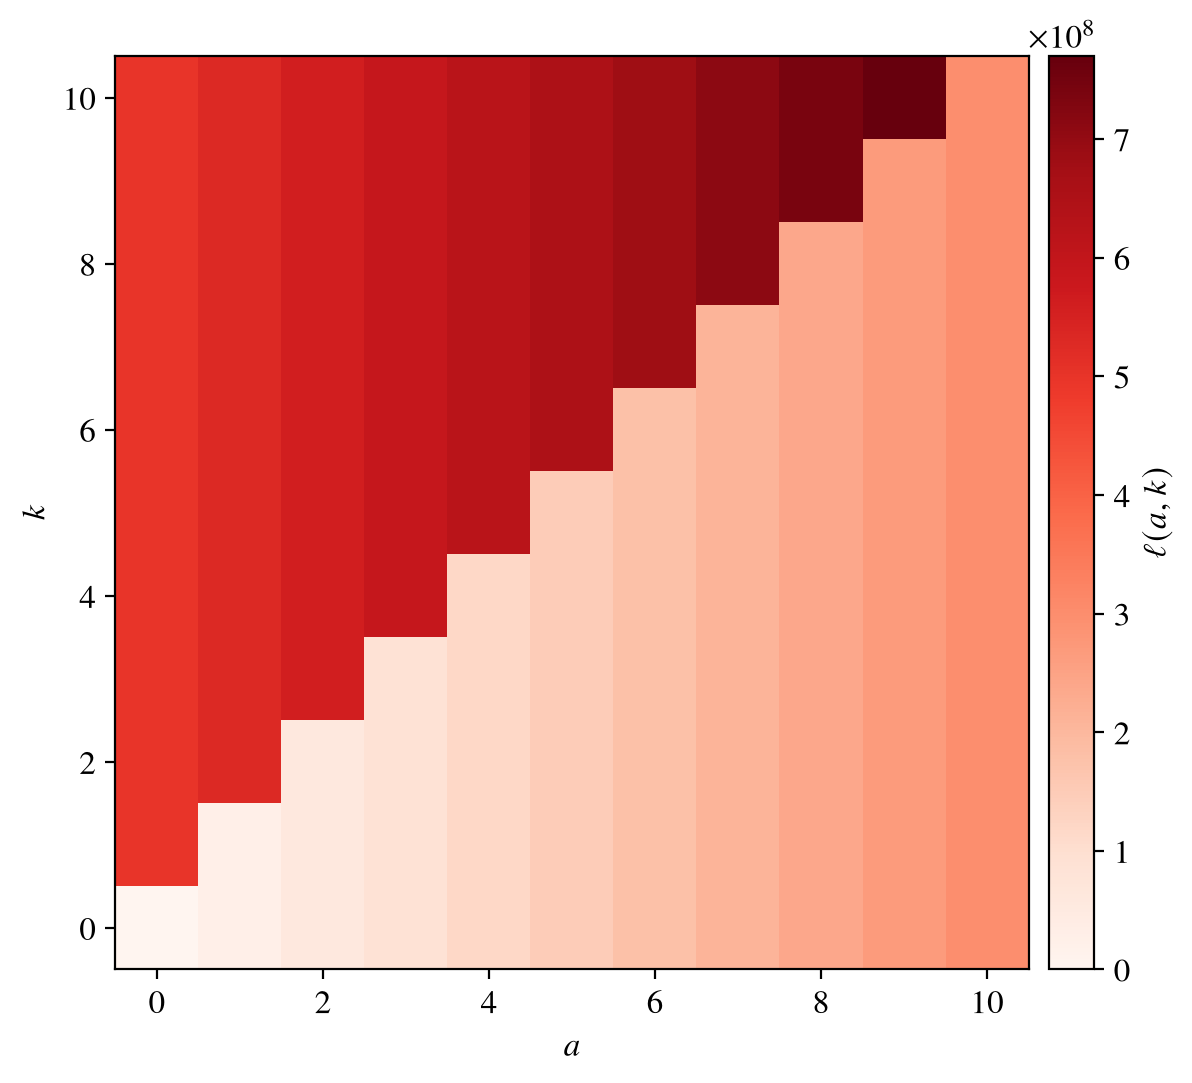

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from plotting import subplotgrid, HALF_SLIDE_DIMS
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable

def loss(a, k, c1=30000000, c2=500000000):
    return a*c1 + (a<k.reshape(-1, 1))*c2

a = np.arange(11)
a = np.arange(11)
l = loss(a, a)

fig, ax = subplotgrid('$a$', '$k$', figsize=HALF_SLIDE_DIMS)
mesh = ax.pcolormesh(a, a, l, cmap='Reds')
ax.set_aspect('equal')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
fig.colorbar(mesh, cax=cax, label=r'$\ell(a, k)$')

display(fig, metadata={'image/png': {'width': '75%'}})
plt.close()

### Step 2: Probabilistic Model

$$
K \sim \mathrm{Poi}(t\lambda)\\
p(k) = \frac{1}{\exp(\lambda)} \frac{\lambda^k}{k!}
$$

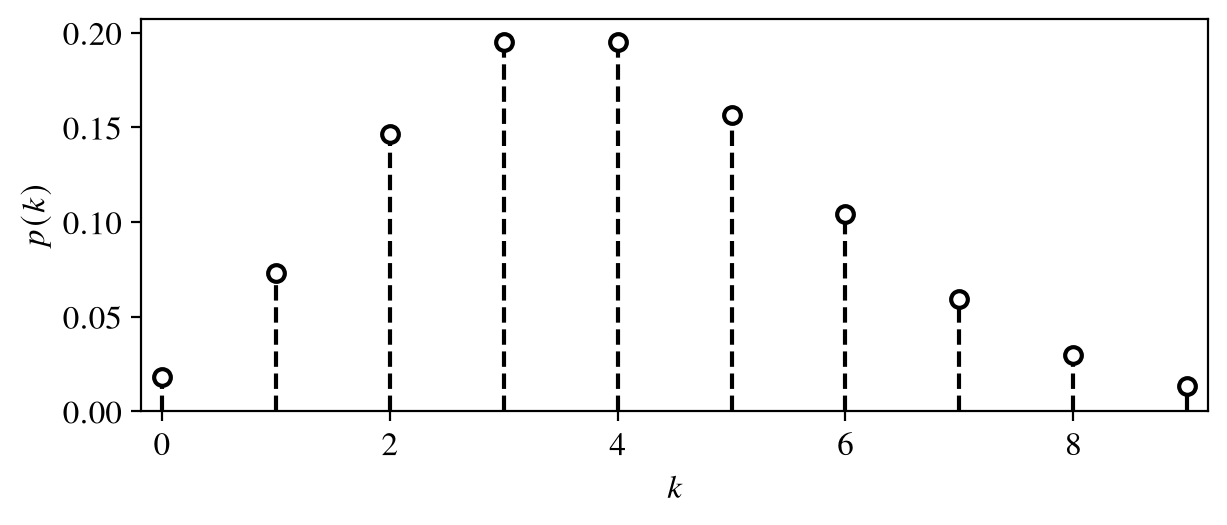

In [2]:
import numpy as np
from scipy.special import gammaln
from plotting import plot_pmf, SLIDE_FIG_DIMS
from matplotlib import pyplot as plt

def poisson_pmf(lam):
    def pmf(k):
        log_p = k * np.log(lam) - lam - gammaln(k + 1)
        return np.exp(log_p)
    return pmf

fig, ax = subplotgrid('$k$', '$p(k)$', figsize=SLIDE_FIG_DIMS/2, xmargins=0.02)
plot_pmf(ax, np.arange(10), poisson_pmf(4))
display(fig, metadata={'image/png': {'width': '75%'}})
plt.close()

### Step 3: Expected Loss

$$
\begin{aligned}
L(a) &= \sum_{k=0}^\infty \ell(a, k) p(k) \\
&=\sum_{k=0}^\infty \left ( ac_1 + \mathbb{I}(a < k)c_2 \right) p(k)\\
&=ac_1 + c_2\sum_{k=a+1}^\infty \,p(k)\\
&=ac_1 + c_2 (1-P(a))
\end{aligned}
$$

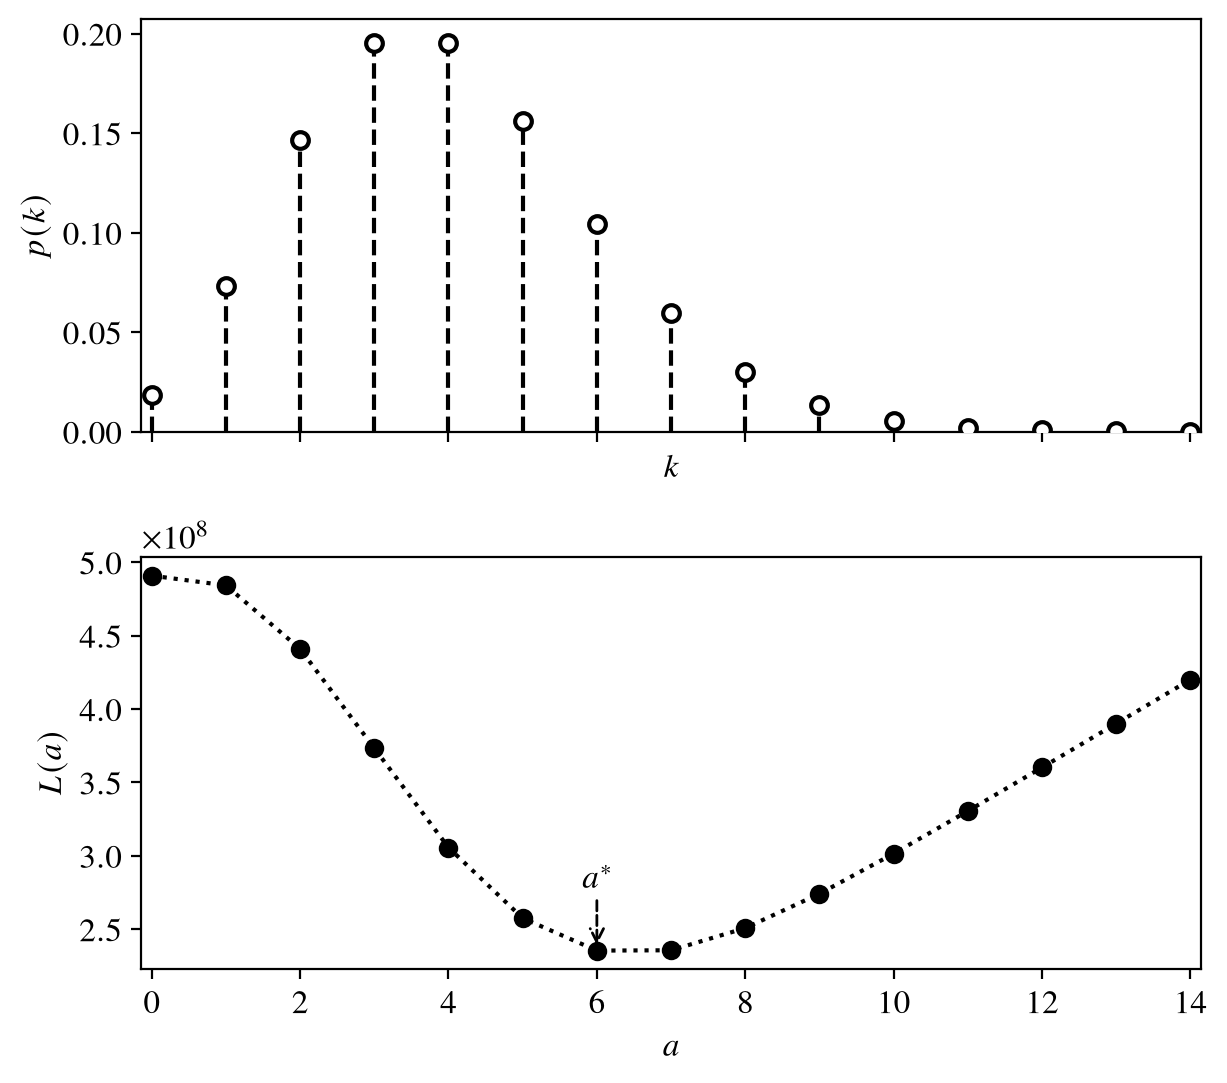

In [36]:
from scipy.stats import poisson

sf = poisson(4).sf

def expected_loss(a, c1=30000000, c2=500000000):
    return a*c1 + sf(a)*c2

fig, ax = subplotgrid(['$k$', '$a$'], ['$p(k)$', '$L(a)$'], rows=2, cols=1, figsize=HALF_SLIDE_DIMS, sharey=False, xmargins=0.01)
a = np.arange(15)
plot_pmf(ax[0], a, poisson_pmf(4))
ax[1].plot(a, expected_loss(a), marker='o', c='k', ls=':')
a_star = np.argmin(expected_loss(a))
ax[1].annotate('$a^*$', xy=(a_star, expected_loss(a_star)), xytext=(0, 20), textcoords='offset points', verticalalignment='bottom', horizontalalignment='center', 
               arrowprops={'arrowstyle': '->', 'linestyle': 'dashed', 'shrinkA': 0, 'shrinkB': 2})
display(fig, metadata={'image/png': {'width': '75%'}})
plt.close()